# Exploratory Data Analysis (EDA)


## 1. Setup & Import


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
import os
import warnings

warnings.filterwarnings('ignore')

RANDOM_SEED = 42
DATA_PATH = '../data/raw/data_antam.csv'

plt.style.use('seaborn-v0_8-whitegrid')

os.makedirs('../reports/figures', exist_ok=True)

## 2. Load & Inspect Data


In [2]:
df = pd.read_csv(DATA_PATH)

display(df.head())

display(df.tail())

,Tanggal,Terakhir,Pembukaan,Tertinggi,Terendah,Vol.,Perubahan%
0,05/05/2026,3.69,3.76,3.76,3.64,"111,55M","-2,89%"
1,04/05/2026,3.80,3.75,3.85,3.74,"81,67M","1,60%"
2,30/04/2026,3.74,3.90,3.91,3.60,"212,84M","-3,61%"
3,29/04/2026,3.88,4.00,4.00,3.88,"93,32M","-3,96%"
4,28/04/2026,4.04,4.12,4.29,3.94,"171,37M","-1,94%"


,Tanggal,Terakhir,Pembukaan,Tertinggi,Terendah,Vol.,Perubahan%
2977,07/01/2014,844.0,840.0,844.0,798.0,"21,26M","0,00%"
2978,06/01/2014,844.0,865.0,882.0,844.0,"17,89M","-3,43%"
2979,03/01/2014,874.0,907.0,907.0,857.0,"24,57M","-3,64%"
2980,02/01/2014,907.0,916.0,932.0,907.0,"15,86M","-0,98%"
2981,01/01/2014,916.0,916.0,941.0,916.0,"18,16M","0,00%"


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2982 entries, 0 to 2981
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Tanggal     2982 non-null   str    
 1   Terakhir    2982 non-null   float64
 2   Pembukaan   2982 non-null   float64
 3   Tertinggi   2982 non-null   float64
 4   Terendah    2982 non-null   float64
 5   Vol.        2982 non-null   str    
 6   Perubahan%  2982 non-null   str    
dtypes: float64(4), str(3)
memory usage: 163.2 KB


In [4]:
missing = df.isnull().sum()
print("Missing values per kolom:\n", missing)

duplicates = df.duplicated().sum()
print(f"\nJumlah baris duplikat: {duplicates}")

Missing values per kolom:
 Tanggal       0
Terakhir      0
Pembukaan     0
Tertinggi     0
Terendah      0
Vol.          0
Perubahan%    0
dtype: int64

Jumlah baris duplikat: 0


## 3. Data Overview


In [5]:
df_viz = df.copy()

df_viz['Tanggal'] = pd.to_datetime(df_viz['Tanggal'], format='%d/%m/%Y')
df_viz = df_viz.sort_values('Tanggal').reset_index(drop=True)

def parse_vol(vol_str):
    if pd.isna(vol_str) or vol_str == '-':
        return 0.0
    vol_str = str(vol_str).upper().replace(',', '.')
    if 'M' in vol_str:
        return float(vol_str.replace('M', '')) * 1_000_000
    elif 'K' in vol_str:
        return float(vol_str.replace('K', '')) * 1_000
    elif 'B' in vol_str:
        return float(vol_str.replace('B', '')) * 1_000_000_000
    return float(vol_str)

df_viz['Vol.'] = df_viz['Vol.'].apply(parse_vol)

for col in ['Terakhir', 'Pembukaan', 'Tertinggi', 'Terendah']:
    if df_viz[col].dtype == object:
        df_viz[col] = df_viz[col].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float)
        
display(df_viz.describe())

,Tanggal,Terakhir,Pembukaan,Tertinggi,Terendah,Vol.
count,2982,2982.000000,2982.000000,2982.000000,2982.000000,2.982000e+03
mean,2020-02-21 04:06:45.633802,382.292882,383.067340,383.139027,383.660205,1.070242e+08
min,2014-01-01 00:00:00,1.000000,1.000000,1.000000,1.000000,1.370000e+06
25%,2017-01-18 06:00:00,2.010000,2.010000,2.030000,2.000000,3.248500e+07
50%,2020-02-18 12:00:00,347.500000,347.000000,326.500000,359.500000,6.186000e+07
75%,2023-03-05 06:00:00,779.250000,780.000000,790.000000,775.000000,1.197150e+08
max,2026-05-05 00:00:00,995.000000,995.000000,995.000000,995.000000,2.190000e+09
std,NaN,385.938164,386.915988,391.486069,382.527593,1.604985e+08


## 4. Visualisasi Harga


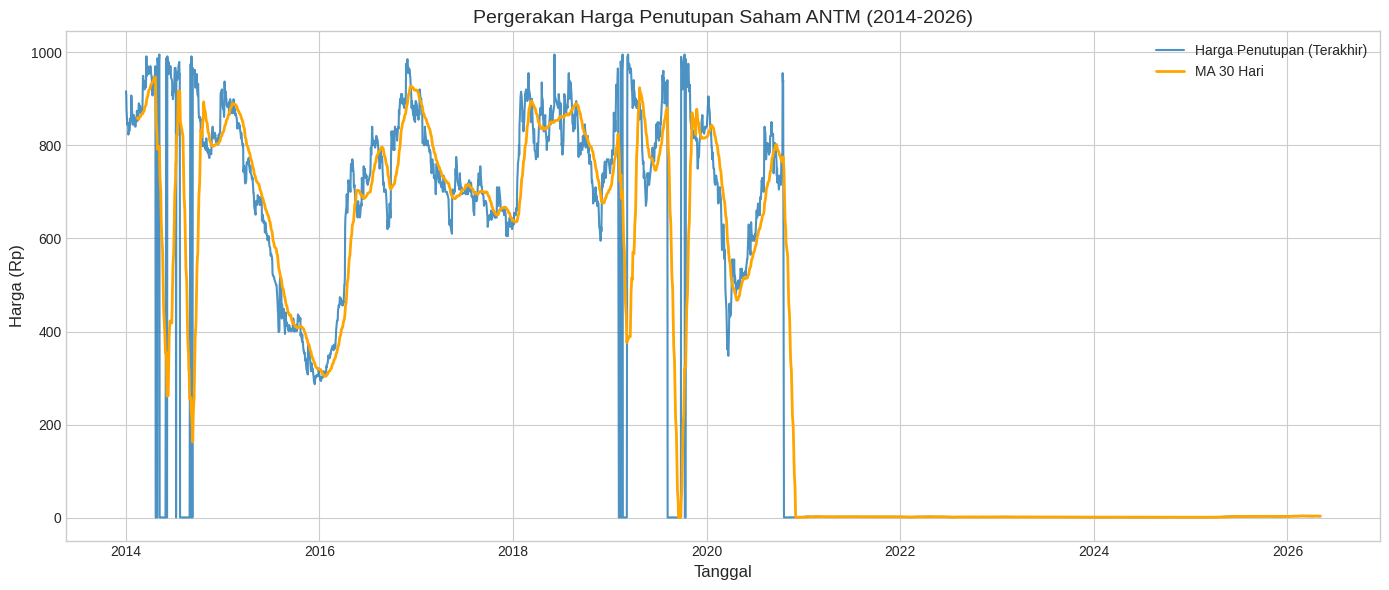

In [6]:
plt.figure(figsize=(14, 6))
plt.plot(df_viz['Tanggal'], df_viz['Terakhir'], label='Harga Penutupan (Terakhir)', alpha=0.8)

ma30 = df_viz['Terakhir'].rolling(window=30).mean()
plt.plot(df_viz['Tanggal'], ma30, label='MA 30 Hari', color='orange', linewidth=2)

plt.title('Pergerakan Harga Penutupan Saham ANTM (2014-2026)', fontsize=14)
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Harga (Rp)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig('../reports/figures/eda_closing_price_ma30.png')
plt.show()

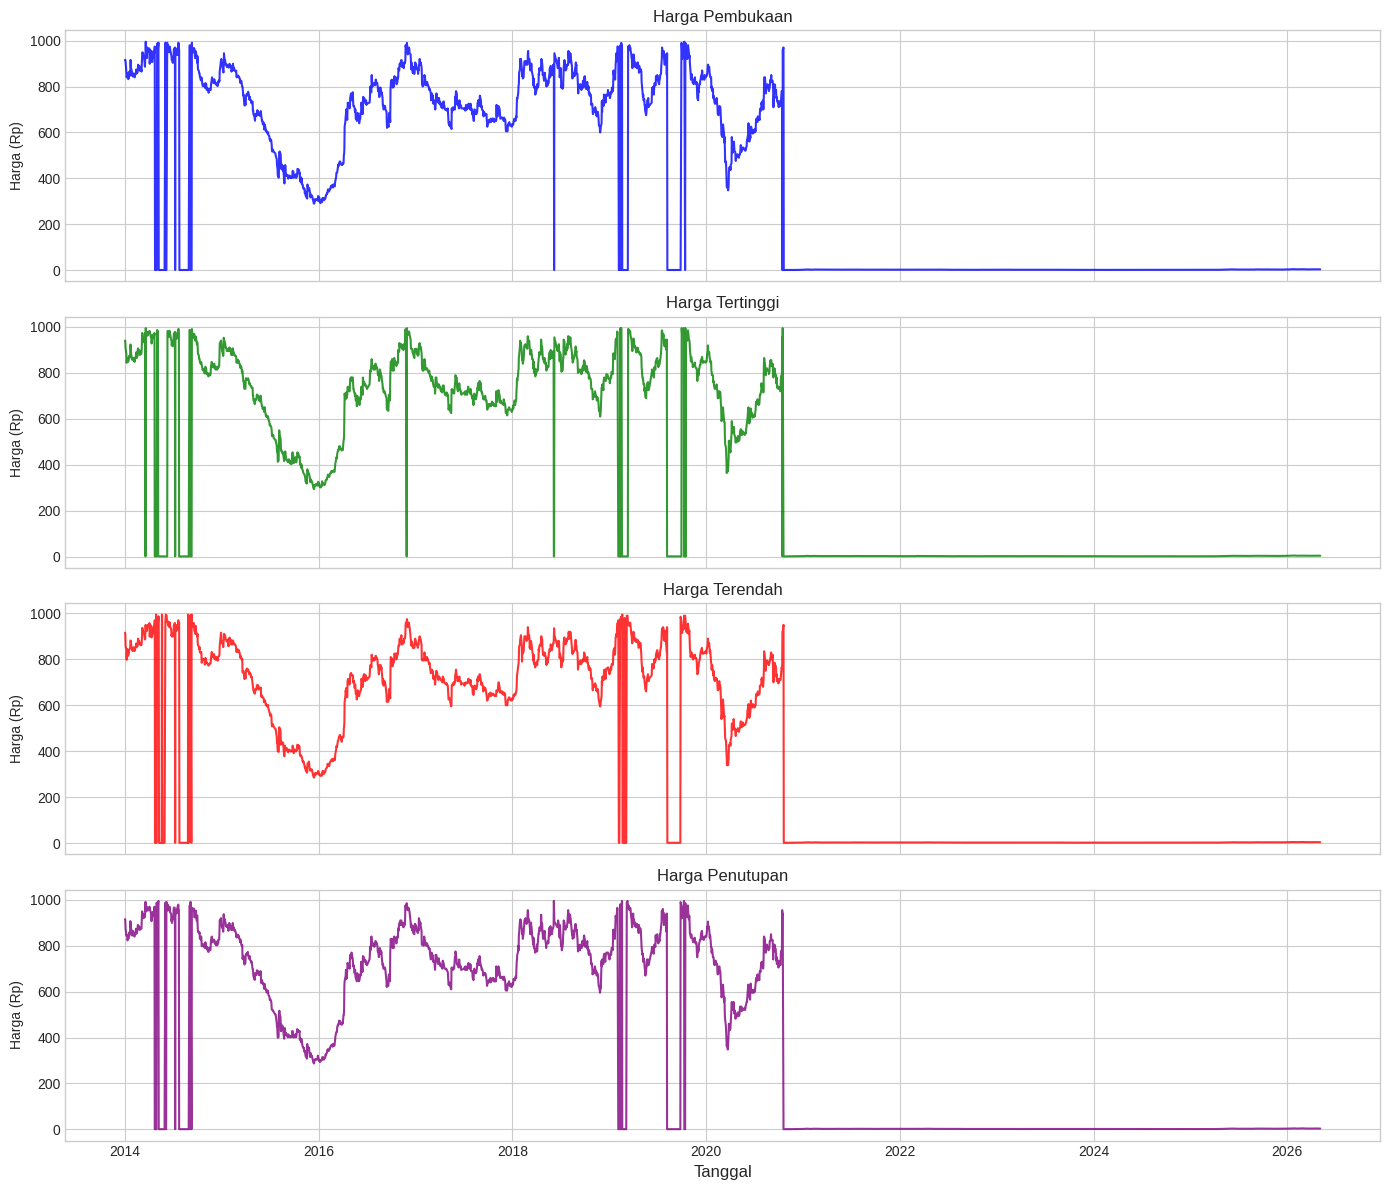

In [7]:
# Subplots OHLC
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

for ax, col, color, title in zip(axes, 
                                 ['Pembukaan', 'Tertinggi', 'Terendah', 'Terakhir'],
                                 ['blue', 'green', 'red', 'purple'],
                                 ['Harga Pembukaan', 'Harga Tertinggi', 'Harga Terendah', 'Harga Penutupan']):
    ax.plot(df_viz['Tanggal'], df_viz[col], color=color, alpha=0.8)
    ax.set_title(title)
    ax.set_ylabel('Harga (Rp)')

axes[-1].set_xlabel('Tanggal', fontsize=12)
plt.tight_layout()
plt.savefig('../reports/figures/eda_ohlc_subplots.png')
plt.show()

## 5. Visualisasi Volume


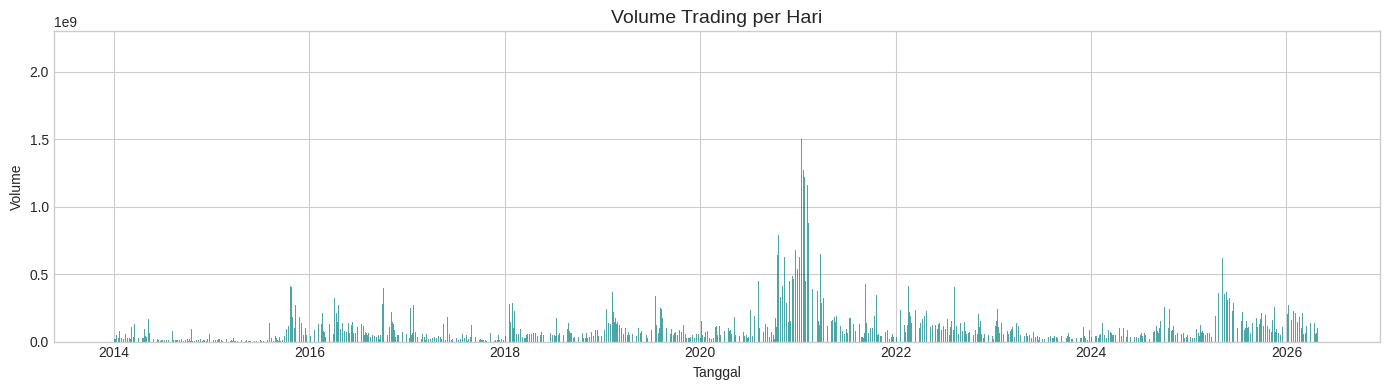

In [8]:
# Bar chart volume
plt.figure(figsize=(14, 4))
plt.bar(df_viz['Tanggal'], df_viz['Vol.'], color='teal', alpha=0.7)
plt.title('Volume Trading per Hari', fontsize=14)
plt.xlabel('Tanggal')
plt.ylabel('Volume')
plt.tight_layout()
plt.savefig('../reports/figures/eda_volume_bar.png')
plt.show()

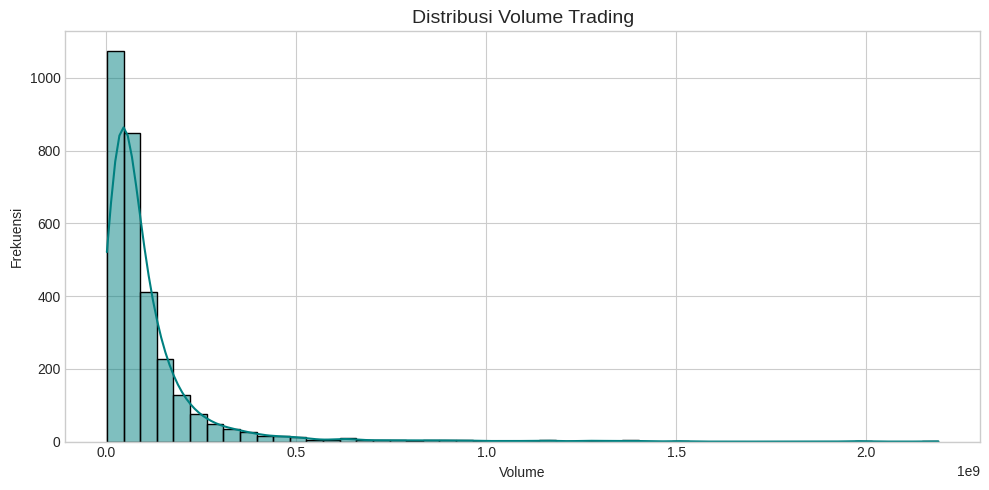

In [9]:
# Histogram volume
plt.figure(figsize=(10, 5))
sns.histplot(df_viz['Vol.'], bins=50, kde=True, color='teal')
plt.title('Distribusi Volume Trading', fontsize=14)
plt.xlabel('Volume')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.savefig('../reports/figures/eda_volume_hist.png')
plt.show()

## 6. Analisis Distribusi & Korelasi


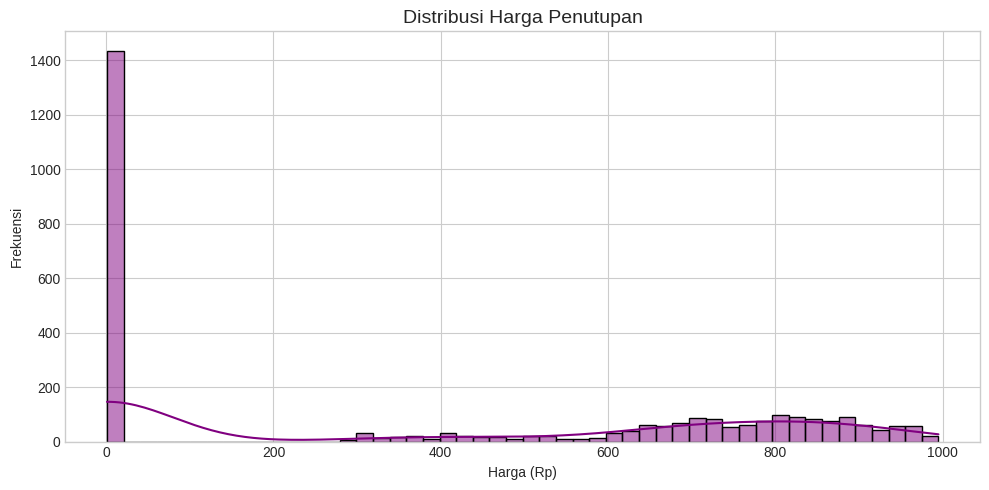

In [10]:
# Histogram distribusi harga penutupan
plt.figure(figsize=(10, 5))
sns.histplot(df_viz['Terakhir'], bins=50, kde=True, color='purple')
plt.title('Distribusi Harga Penutupan', fontsize=14)
plt.xlabel('Harga (Rp)')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.savefig('../reports/figures/eda_closing_price_hist.png')
plt.show()

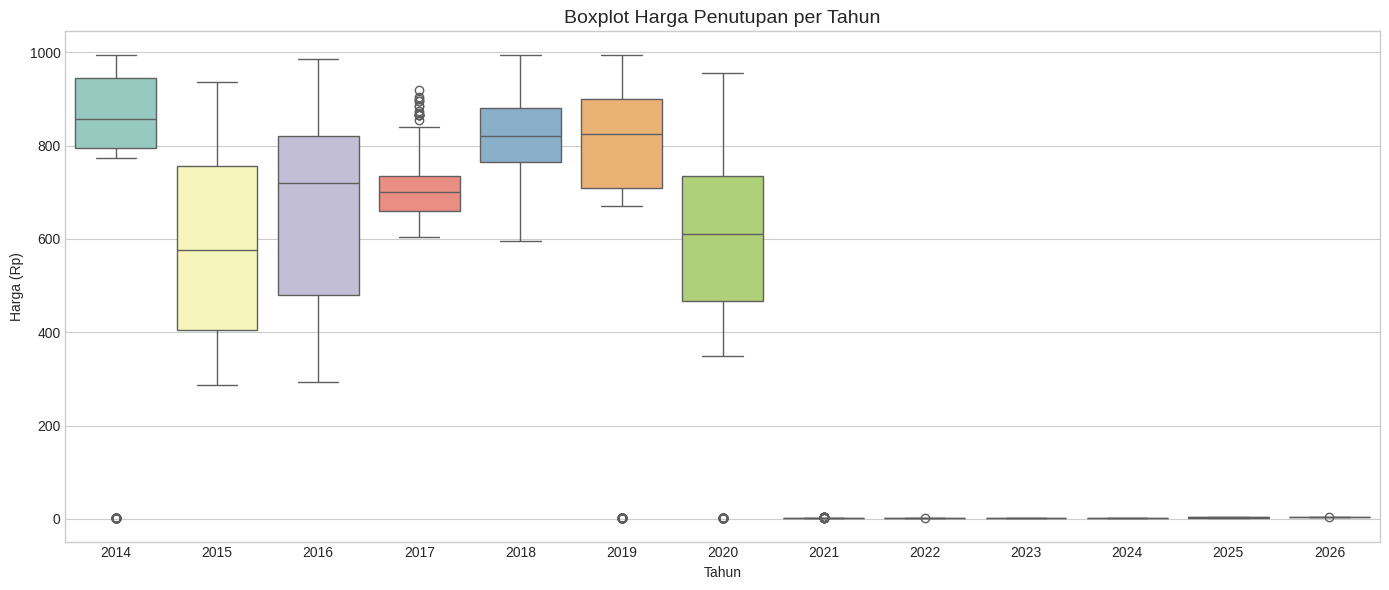

In [11]:
# Boxplot harga per tahun
df_viz['Tahun'] = df_viz['Tanggal'].dt.year

plt.figure(figsize=(14, 6))
sns.boxplot(x='Tahun', y='Terakhir', data=df_viz, palette='Set3')
plt.title('Boxplot Harga Penutupan per Tahun', fontsize=14)
plt.xlabel('Tahun')
plt.ylabel('Harga (Rp)')
plt.tight_layout()
plt.savefig('../reports/figures/eda_closing_price_boxplot.png')
plt.show()

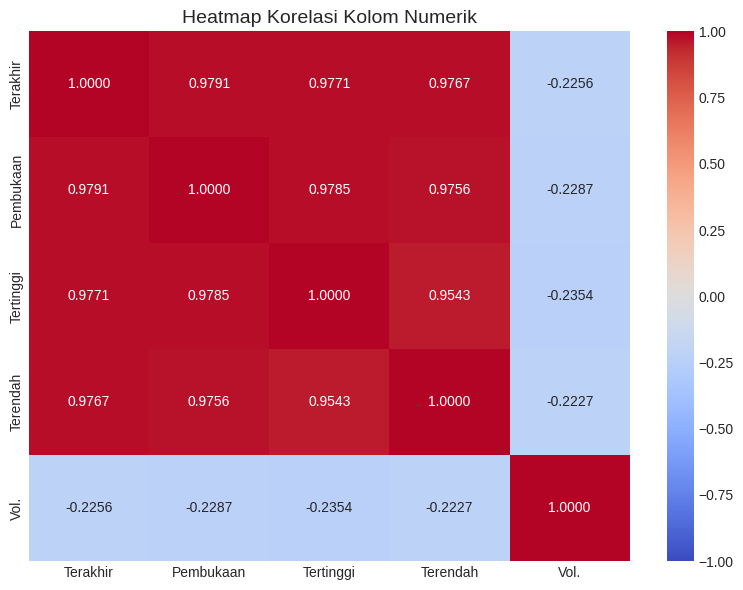

In [12]:
# Heatmap korelasi
numeric_cols = ['Terakhir', 'Pembukaan', 'Tertinggi', 'Terendah', 'Vol.']
corr = df_viz[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.4f')
plt.title('Heatmap Korelasi Kolom Numerik', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/figures/eda_correlation_heatmap.png')
plt.show()

## 7. Uji Stasioneritas


In [13]:
def run_adf_test(series, title=""):
    print(f"--- ADF Test: {title} ---")
    result = adfuller(series.dropna())
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    print("Critical Values:")
    for key, value in result[4].items():
        print(f"  {key}: {value:.4f}")
    
    if result[1] <= 0.05:
        print("Kesimpulan: Data STASIONER (Tolak H0)\n")
    else:
        print("Kesimpulan: Data TIDAK STASIONER (Gagal Tolak H0)\n")

# ADF test pada data asli
run_adf_test(df_viz['Terakhir'], "Harga Penutupan Asli")

# ADF test pada data differencing (diff 1)
run_adf_test(df_viz['Terakhir'].diff(), "Harga Penutupan Differencing 1st Order")

--- ADF Test: Harga Penutupan Asli ---
ADF Statistic: -2.7975
p-value: 0.0586
Critical Values:
  1%: -3.4326
  5%: -2.8625
  10%: -2.5673
Kesimpulan: Data TIDAK STASIONER (Gagal Tolak H0)

--- ADF Test: Harga Penutupan Differencing 1st Order ---
ADF Statistic: -12.5381
p-value: 0.0000
Critical Values:
  1%: -3.4326
  5%: -2.8625
  10%: -2.5673
Kesimpulan: Data STASIONER (Tolak H0)

